# Mapa de similaridade + Propagação de notícias entre canais

**Objetivo:** usar embeddings semânticos (Semantic BERT) para
1. achar notícias **duplicadas / quase-duplicadas** (a mesma matéria saindo em vários jornais);
2. plotar um **mapa de similaridade** onde as matérias repetidas ficam juntas;
3. plotar um **grafo de propagação** mostrando **de onde a notícia partiu** e por quais canais ela se espalhou.


## 1. Setup

In [1]:
!pip install -q sentence-transformers umap-learn networkx plotly nltk 2>/dev/null

In [2]:
import re, time, warnings
import numpy as np, pandas as pd
from bs4 import BeautifulSoup
from collections import Counter
import torch
import matplotlib.pyplot as plt
import networkx as nx
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

device: cuda


## 2. Parâmetros

In [3]:
SAMPLE_SIZE     = 3000
EMBED_MODEL     = 'paraphrase-multilingual-mpnet-base-v2'
SIM_DUP         = 0.88
LEX_DUP         = 0.30
MIN_PALAVRAS    = 20
SEED            = 42
TOP_FONTES_PLOT = 25
MIN_PESO_ARESTA = 2

## 3. Dados + limpeza

Estrutura esperada do CSV: `data_publicacao`, `titulo`, `fonte`, `texto`, `flagnoticia`.

In [4]:
from google.colab import files
up = files.upload()
df = pd.read_csv(list(up.keys())[0])
df = df.dropna(subset=['texto','titulo','fonte','data_publicacao']).reset_index(drop=True)

df['dt']  = pd.to_datetime(df['data_publicacao'], errors='coerce')
df = df.dropna(subset=['dt']).reset_index(drop=True)
df['dia'] = df['dt'].dt.normalize()

_BOILER = re.compile(
    r'(?i)\b(compartilh\w*|curtir|siga[- ]?nos|whatsapp|facebook|twitter|linkedin|'
    r'instagram|telegram|imprimir|newsletter|assine|cadastre[- ]?se|'
    r'leia\s+(tamb\w+|mais)|veja\s+(tamb\w+|mais)|saiba\s+mais|clique\s+aqui|'
    r'publicidade|todos\s+os\s+direitos\s+reservados|divulga\w+|reprodu\w+)\b')
_HORAS = re.compile(r'(?i)\b(seg|ter|qua|qui|sex|s[aá]b|dom)\b'
                    r'(\s*(a|e|,|/|-)\s*(seg|ter|qua|qui|sex|s[aá]b|dom)\b)+')

def limpa(t):
    if not isinstance(t, str): return ''
    t = BeautifulSoup(t, 'html.parser').get_text(' ').replace('\\n', ' ')
    t = re.sub(r'[\x00-\x1f\x7f]', ' ', t)
    t = _HORAS.sub(' ', t)
    t = _BOILER.sub(' ', t)
    return re.sub(r'\s+', ' ', t).strip()

df['txt'] = df['titulo'].fillna('') + '. ' + df['texto'].apply(limpa)
df = df[df['txt'].str.split().str.len() >= MIN_PALAVRAS].reset_index(drop=True)

if SAMPLE_SIZE:
    df = df.sample(min(SAMPLE_SIZE, len(df)), random_state=SEED).reset_index(drop=True)

print(len(df), 'noticias |', df['fonte'].nunique(), 'fontes |',
      df['dia'].min().date(), '->', df['dia'].max().date())
df[['data_publicacao','fonte','titulo']].head()

Saving investimento_2016_2024.csv to investimento_2016_2024.csv
3000 noticias | 54 fontes | 2016-01-01 -> 2024-12-28


,data_publicacao,fonte,titulo
0,2019-08-08 00:00:00,Correio Popular - Impresso - Flip,Odata inicia construção de data center em Hort...
1,2023-12-30 03:00:00,O Imparcial Online,Ronaldo Fernandes volta a PP com os carros elé...
2,2016-08-02 00:00:00,Associação Brasileira de Concessionárias de Ro...,Intervias inicia obras das marginais de Itapira
3,2021-06-29 00:00:00,Valor Econômico,Petrobras vai investir em diesel na Replan
4,2023-06-02 03:00:00,Correio Popular,Lula chega ao auditório da UFABC para inaugura...


## 4. Embeddings semânticos (Semantic BERT)

Cada notícia vira um vetor. Vetores próximos = textos com significado parecido.
`normalize_embeddings=True` faz o produto interno já ser o **cosseno**.

In [5]:
from sentence_transformers import SentenceTransformer, util

model = SentenceTransformer(EMBED_MODEL, device=DEVICE)
t0 = time.time()
emb = model.encode(df['txt'].tolist(), batch_size=32, convert_to_tensor=True,
                   show_progress_bar=True, normalize_embeddings=True)
print('embeddings:', tuple(emb.shape), '|', round(time.time()-t0, 1), 's')

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/5.12k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/94 [00:00<?, ?it/s]

embeddings: (3000, 768) | 19.4 s


## 5. Achar os pares duplicados

`paraphrase_mining` compara tudo de forma eficiente (em blocos, sem montar a matriz N×N inteira)
e devolve os pares mais parecidos. Ficamos só com os que passam de `SIM_DUP`.

In [6]:
t0 = time.time()
pares = util.paraphrase_mining_embeddings(emb, top_k=20, corpus_chunk_size=2048)
print('pares avaliados:', len(pares), '|', round(time.time()-t0, 1), 's')

dups = [(s, i, j) for s, i, j in pares if s >= SIM_DUP]
print(len(dups), 'pares duplicados (sim >=', SIM_DUP, ')')
if not dups:
    print('>> nenhum par encontrado: baixe o SIM_DUP (ex.: 0.70) e rode de novo')

pd.DataFrame([
    {'sim': round(s, 3),
     'fonte_A': df.fonte[i], 'data_A': df.dia[i].date(), 'titulo_A': df.titulo[i][:50],
     'fonte_B': df.fonte[j], 'data_B': df.dia[j].date(), 'titulo_B': df.titulo[j][:50]}
    for s, i, j in dups[:40]])

pares avaliados: 104353 | 0.9 s
702 pares duplicados (sim >= 0.88 )


,sim,fonte_A,data_A,titulo_A,fonte_B,data_B,titulo_B
0,1.0,Valor Econômico - Impresso,2017-09-26,Toyota investe R$ 1 bi para montar novo carro ...,Valor Econômico,2017-09-26,Toyota investe R$ 1 bi para montar novo carro ...
1,1.0,Folha da Região,2016-04-23,Scania inaugura laboratório e foca mercado ext...,Araraquara,2016-04-23,Scania inaugura laboratório e foca mercado ext...
2,1.0,Folha da Região,2019-01-23,Admissão no varejo é a maior em 4 anos,DCI Online,2019-01-23,Admissão no varejo é a maior em 4 anos
3,1.0,Diário do Grande ABC,2017-12-29,'2018 será nosso maior ano de investimento',Folha da Região,2017-12-29,'2018 será nosso maior ano de investimento'
4,1.0,Estadão,2018-08-08,Drogaria Onofre reforça vendas online e terá n...,Guarulhos Web,2018-08-08,Drogaria Onofre reforça vendas online e terá n...
5,1.0,Diário do Grande ABC,2018-04-08,Empreendedores saudáveis,Folha da Região,2018-04-08,Empreendedores saudáveis
6,1.0,Guarulhos Web,2018-09-01,Mercado Livre vai testar entregas em até um dia,Correio Popular,2018-09-01,Mercado Livre vai testar entregas em até um dia
7,1.0,Valor Econômico - Impresso,2019-03-14,Fábrica da Qualcomm e USI será em Jaguariúna,Valor Econômico,2019-03-14,Fábrica da Qualcomm e USI será em Jaguariúna
8,1.0,Folha da Região,2017-06-20,Chinesa BYD firma convênio de R$ 5 milhões com...,Guarulhos Web,2017-06-20,Chinesa BYD firma convênio de R$ 5 milhões com...
9,1.0,Valor Econômico,2019-02-21,Sabin compra 17% da rede Amparo,Valor Econômico - Impresso - Flip,2019-02-21,Sabin compra 17% da rede Amparo


## 6. Agrupar as notícias iguais


In [17]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import defaultdict

emb_np  = emb.cpu().numpy()

sim_sem = np.clip(emb_np @ emb_np.T, -1, 1)

tfv = TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2,
                      token_pattern=r'(?u)\b\w[\w,]+\b', max_features=60000)
T       = tfv.fit_transform(df['txt'])
sim_lex = (T @ T.T).toarray()

dist = (1.0 - sim_sem).astype(np.float64)
dist[sim_lex < LEX_DUP] = 1.0
np.fill_diagonal(dist, 0.0)

try:
    cl = AgglomerativeClustering(n_clusters=None, metric='precomputed',
                                 linkage='complete', distance_threshold=1 - SIM_DUP)
except TypeError:
    cl = AgglomerativeClustering(n_clusters=None, affinity='precomputed',
                                 linkage='complete', distance_threshold=1 - SIM_DUP)
labels = cl.fit_predict(dist)

buckets = defaultdict(list)
for idx, lb in enumerate(labels):
    buckets[lb].append(idx)
materias = sorted([set(v) for v in buckets.values() if len(v) >= 2],
                  key=len, reverse=True)

df['cluster'] = -1
for cid, c in enumerate(materias):
    for n in c:
        df.loc[n, 'cluster'] = cid

dups = []
for c in materias:
    cs = sorted(c)
    for a in range(len(cs)):
        for b in range(a + 1, len(cs)):
            i, j = cs[a], cs[b]
            dups.append((float(sim_sem[i, j]), i, j))

print(len(materias), 'materias repetidas |',
      int((df.cluster >= 0).sum()), 'noticias agrupadas |', len(dups), 'pares')
tam = pd.Series([len(c) for c in materias])
print('maiores materias (no de copias):', list(tam.head(8)))

alto = np.triu(sim_sem >= SIM_DUP, k=1) & (sim_lex < LEX_DUP)
rej  = [(sim_sem[i, j], sim_lex[i, j], i, j) for i, j in zip(*np.where(alto))]
rej.sort(reverse=True)
print(f'\n{len(rej)} pares reprovados pelo gate lexico (mesmo assunto, materia diferente). exemplos:')
for s, l, i, j in rej[:5]:
    print(f'  sem={s:.3f}  lex={l:.3f}')
    print(f'     - [{df.fonte[i]}] {str(df.titulo[i])[:62]}')
    print(f'     - [{df.fonte[j]}] {str(df.titulo[j])[:62]}')

if materias:
    big = sorted(materias[0])
    print(f'\nmaior grupo = {len(big)} noticias | sim semantica min interna =',
          round(float(sim_sem[np.ix_(big, big)].min()), 3),
          '| sim lexica min interna =',
          round(float(sim_lex[np.ix_(big, big)].min()), 3))
    print('    se os titulos abaixo forem de assuntos diferentes, suba o LEX_DUP:')
    for n in big[:8]:
        print(f'     - [{df.fonte[n]}] {str(df.titulo[n])[:66]}')

173 materias repetidas | 362 noticias agrupadas | 207 pares
maiores materias (no de copias): [4, 4, 3, 3, 3, 3, 3, 3]

448 pares reprovados pelo gate lexico (mesmo assunto, materia diferente). exemplos:
  sem=0.956  lex=0.265
     - [A Tribuna] [JOR-TER] Porto de Santos movimenta 7 milhões de toneladas
     - [A Tribuna] MRS chega à marca de 1 mi de toneladas de cargas transportadas
  sem=0.950  lex=0.162
     - [Valor Econômico - Impresso - Flip] Car­re­four e GPA ace­le­ram pro­mo­ções
     - [DCI Online] Fabricantes de salgadinhos buscam adaptação às mudanças no con
  sem=0.947  lex=0.251
     - [Estadão] Sabesp obtém R$ 470 milhões do BID para expandir saneamento na
     - [Diário do Grande ABC] Sabesp vai captar R$ 2,5 bi para investir em saneamento
  sem=0.947  lex=0.204
     - [A Tribuna] Fíbria aumentará sua capacidade produtiva em 33%
     - [A Tribuna] ADM conclui construção de novo armazém
  sem=0.946  lex=0.080
     - [DCI Online] Eletropaulo vai investir R$ 4,9 bi entre 20

## 7. Agrupar por tópico (assuntos parecidos, não idênticos)

Como funciona (receita estilo BERTopic, sem a biblioteca):

1. reduz os embeddings pra poucas dimensões com UMAP (ajuda a densidade);
2. agrupa com HDBSCAN, que acha o número de tópicos sozinho e joga o que
   não encaixa em lugar nenhum no rótulo `-1` (sem tópico);
3. dá nome a cada tópico com as palavras mais características (c-TF-IDF).


In [16]:
MIN_TOPICO      = 20
TOPICO_DIM      = 5
TOPICO_NEIGHBOR = 15

import umap, numpy as np

if 'emb_np' not in globals():
    emb_np = emb.cpu().numpy()

t0 = time.time()
X_topico = umap.UMAP(n_neighbors=TOPICO_NEIGHBOR, n_components=TOPICO_DIM,
                     min_dist=0.0, metric='cosine',
                     random_state=SEED).fit_transform(emb_np)
print('umap p/ topico', round(time.time() - t0, 1), 's')

try:
    from sklearn.cluster import HDBSCAN
    clt = HDBSCAN(min_cluster_size=MIN_TOPICO, metric='euclidean')
except ImportError:
    import hdbscan
    clt = hdbscan.HDBSCAN(min_cluster_size=MIN_TOPICO, metric='euclidean')
lab = clt.fit_predict(X_topico)

real = lab >= 0
ids_real = np.array(sorted(set(lab[real])))
cent = np.vstack([emb_np[lab == c].mean(0) for c in ids_real])
cent /= np.linalg.norm(cent, axis=1, keepdims=True)
if (~real).any():
    lab[~real] = ids_real[(emb_np[~real] @ cent.T).argmax(1)]
df['topico'] = lab

print(len(ids_real), 'topicos |',
      list(pd.Series(lab).value_counts().head(8).values))


umap p/ topico 46.0 s
25 topicos | [np.int64(292), np.int64(258), np.int64(247), np.int64(198), np.int64(198), np.int64(196), np.int64(164), np.int64(157)]


In [9]:
from sklearn.feature_extraction.text import CountVectorizer
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
STOP_PT = stopwords.words('portuguese')

vec = CountVectorizer(lowercase=True, stop_words=STOP_PT,
                      token_pattern=r'(?u)\b[a-zà-ÿ]{3,}\b',
                      ngram_range=(1, 2), min_df=3, max_df=0.35, max_features=30000)
X_art  = vec.fit_transform(df['txt'])
termos = np.array(vec.get_feature_names_out())

ids = sorted(df['topico'].unique())
X = np.vstack([np.asarray(X_art[df['topico'].values == t].sum(axis=0)).ravel()
               for t in ids]).astype(float)

n_tp = X.shape[0]
tf   = X / np.clip(X.sum(axis=1, keepdims=True), 1, None)
idf  = np.log(n_tp / np.clip((X > 0).sum(axis=0), 1, None)) if n_tp > 1 else np.ones(X.shape[1])
ctfidf = tf * idf

TOP_K = 8
palavras = {tid: termos[np.argsort(-ctfidf[r])[:TOP_K]].tolist()
            for r, tid in enumerate(ids)}
label = {tid: ', '.join(w[:3]) for tid, w in palavras.items()}
df['topico_label'] = df['topico'].map(label)

resumo = (df.groupby('topico')
          .agg(noticias=('txt', 'size'), fontes=('fonte', 'nunique')).reset_index())
resumo['palavras'] = resumo['topico'].map(lambda t: ', '.join(palavras[t]))
resumo = resumo.sort_values('noticias', ascending=False).reset_index(drop=True)
resumo.to_csv('topicos_resumo.csv', index=False)
print('salvo: topicos_resumo.csv')
resumo.head(20)

salvo: topicos_resumo.csv


,topico,noticias,fontes,palavras
0,11,292,34,"porto santos, metrô, cptm, trecho, lilás, conc..."
1,13,258,33,"estac, seg sáb, tel seg, sáb dom, seg, sáb, li..."
2,17,247,27,"nestlé, oxxo, scania, ovos, soja, regenerativa..."
3,12,198,32,"drinques, bar, coquetéis, molho, chef, negroni..."
4,2,198,29,"toyota, honda, ford, montadora, volkswagen, se..."
5,10,196,34,"lençóis, macatuba, lençóis paulista, intimação..."
6,19,164,22,"hering, livrarias, livraria, outlets, marketpl..."
7,18,157,24,"fintechs, sky, corretora, iot, stix, easynvest..."
8,16,151,29,"sesc, cine, teatro, sesc mogi, sicredi, espetá..."
9,21,139,17,"scania, advent, carrefour, assaí, órama, gpa, ..."


## 7d. Mapa unificado (junta os dois problemas)

Um mapa só que responde as duas perguntas ao mesmo tempo:

- **tamanho do nó** = quantas cópias iguais aquela matéria teve (seção 6);
- **cor e região** = a que tópico/assunto ela pertence (seção 7c).

Cada bolha grande é uma matéria repetida, posicionada no meio das suas cópias.
As bolinhas pequenas são notícias soltas (sem cópia), coloridas pelo tópico.
As manchas ao fundo são as regiões de cada tópico, só pra guiar o olho.

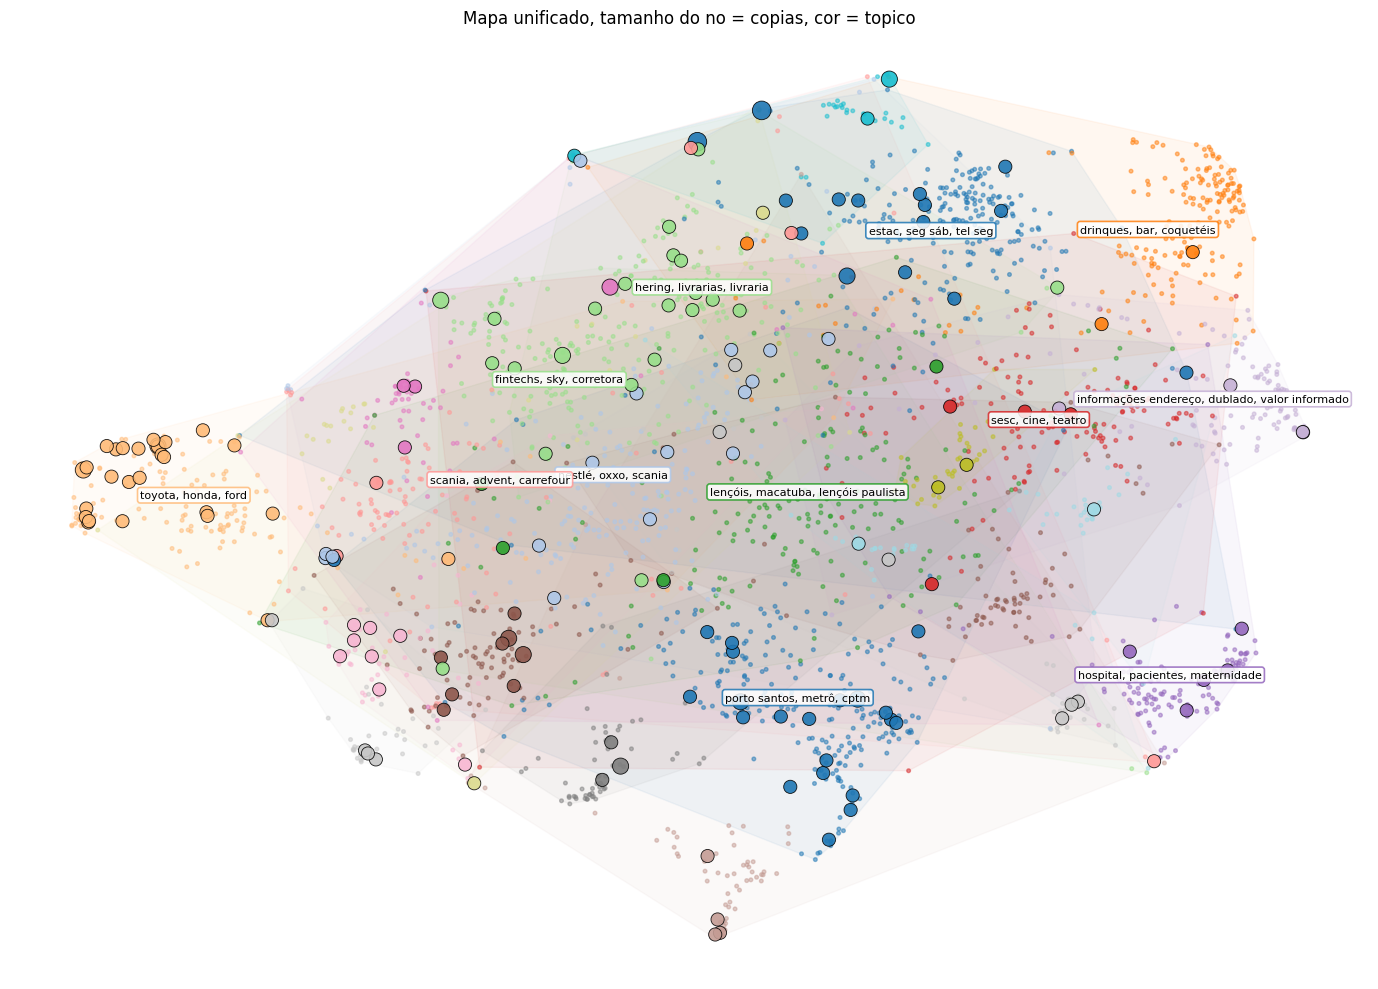

In [10]:
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

if 'xy' not in globals():
    import umap
    xy = umap.UMAP(n_neighbors=30, min_dist=0.05, metric='cosine',
                   random_state=SEED).fit_transform(emb_np)

top_ids = df.topico.value_counts().index.tolist()
paleta  = plt.cm.tab20(np.linspace(0, 1, max(len(top_ids), 1)))
cor     = {t: paleta[k] for k, t in enumerate(top_ids)}

nos = []
for comp in materias:
    comp = list(comp); s = df.iloc[comp]
    primeiro = s.sort_values('dt').iloc[0]
    nos.append(dict(x=xy[comp, 0].mean(), y=xy[comp, 1].mean(), n=len(comp),
                    topico=int(s['topico'].mode().iat[0]), fontes=s['fonte'].nunique(),
                    titulo=str(primeiro['titulo']), fonte0=str(primeiro['fonte']),
                    dia0=primeiro['dt'].date()))

plt.figure(figsize=(14, 10))
for t in top_ids:
    P = xy[df.topico.values == t]
    if len(P) >= 3:
        try:
            poly = P[ConvexHull(P).vertices]
            plt.fill(poly[:, 0], poly[:, 1], color=cor[t], alpha=.06, zorder=0)
        except Exception:
            pass

m1 = df.cluster.values < 0
plt.scatter(xy[m1, 0], xy[m1, 1], s=7,
            c=[cor[t] for t in df.topico.values[m1]], alpha=.5, zorder=1)

nx_ = np.array([d['x'] for d in nos]); ny_ = np.array([d['y'] for d in nos])
nn  = np.array([d['n'] for d in nos]); nc = [cor[d['topico']] for d in nos]
plt.scatter(nx_, ny_, s=45 * nn, c=nc, edgecolors='black',
            linewidths=.6, alpha=.9, zorder=2)

for t in top_ids[:12]:
    P = xy[df.topico.values == t]
    plt.annotate(label[t], (P[:, 0].mean(), P[:, 1].mean()), fontsize=8,
                 ha='center', va='center', zorder=3,
                 bbox=dict(boxstyle='round,pad=.25', fc='white', ec=cor[t],
                           alpha=.85, lw=1.2))

plt.title('Mapa unificado, tamanho do no = copias, cor = topico')
plt.axis('off'); plt.tight_layout(); plt.show()

In [11]:
import plotly.graph_objects as go

def rgb(c): return 'rgb(%d,%d,%d)' % tuple(int(255 * x) for x in c[:3])

fig = go.Figure()
for t in top_ids:
    m = (df.topico.values == t) & (df.cluster.values < 0)
    if m.sum() == 0:
        continue
    fig.add_trace(go.Scatter(
        x=xy[m, 0], y=xy[m, 1], mode='markers', hoverinfo='skip',
        name=label[t][:26], marker=dict(size=5, color=rgb(cor[t]), opacity=.5)))

hx = [d['x'] for d in nos]; hy = [d['y'] for d in nos]
hs = [np.sqrt(d['n']) * 10 + 6 for d in nos]
hc = [rgb(cor[d['topico']]) for d in nos]
ht = [f"<b>{d['titulo'][:90]}</b><br>{d['n']}x copias - {d['fontes']} canais<br>"
      f"topico: {label[d['topico']]}<br>1a: {d['fonte0']} ({d['dia0']})" for d in nos]
fig.add_trace(go.Scatter(
    x=hx, y=hy, mode='markers', text=ht, hoverinfo='text', name='materias (copias)',
    marker=dict(size=hs, color=hc, line=dict(width=.8, color='black'), opacity=.92)))

fig.update_layout(template='plotly_white', height=800,
                  title='Unificado, bolha maior = mais copias, cor = topico',
                  xaxis=dict(visible=False), yaxis=dict(visible=False),
                  legend=dict(font=dict(size=9)), margin=dict(l=10, r=10, t=50, b=10))
fig.show()

## 8. De onde a notícia partiu?

Regra (por **dia**, ignorando a hora de extração):

- **1 só fonte no dia mais antigo** → ela é a origem; as fontes de dias posteriores são seguidoras → aresta `origem → seguidor`.
- **Várias fontes no mesmo dia mais antigo** (empate por causa da hora de extração) → não dá pra dizer qual foi a 1ª entre elas; todas contam como pioneiras e ligam às fontes de dias *posteriores*.
- **Matéria 100% no mesmo dia** → direção indeterminada, fica de fora do grafo.

In [12]:
fluxo          = Counter()

origem_count   = Counter()
seguidor_count = Counter()
status = Counter()

for c in materias:
    sub  = df.loc[sorted(c), ['fonte', 'dia']].sort_values('dia')
    dia0 = sub['dia'].iloc[0]
    pioneiras  = sub[sub.dia == dia0]['fonte'].unique()
    seguidoras = [f for f in sub[sub.dia > dia0]['fonte'].unique() if f not in pioneiras]

    if len(seguidoras) == 0:
        status['tudo_mesmo_dia'] += 1
        continue
    status['direcao_clara' if len(pioneiras) == 1 else 'empate_no_dia'] += 1
    for org in pioneiras:
        origem_count[org] += 1
        for s in seguidoras:
            fluxo[(org, s)] += 1
    for s in seguidoras:
        seguidor_count[s] += 1

print('direcao clara  :', status['direcao_clara'])
print('empate no dia  :', status['empate_no_dia'])
print('tudo mesmo dia :', status['tudo_mesmo_dia'])

edges = (pd.DataFrame([(a, b, w) for (a, b), w in fluxo.items()],
                      columns=['origem', 'seguidor', 'peso'])
         .sort_values('peso', ascending=False).reset_index(drop=True))
print('\narestas de propagacao:', len(edges))
edges.head(15)

direcao clara  : 41
empate no dia  : 3
tudo mesmo dia : 129

arestas de propagacao: 45


,origem,seguidor,peso
0,DCI Online,Jornal da Cidade de Bauru - JCNET,2
1,Folha de S. Paulo,Folha da Região,2
2,Valor Econômico - Impresso,DCI Online,2
3,Valor Econômico - Impresso - Flip,Valor Econômico,2
4,Estadão,Jornal da Cidade de Bauru - JCNET,2
5,Valor Econômico,DCI Online,1
6,Cruzeiro do Sul,Correio Popular,1
7,Folha de S. Paulo,Valor Econômico,1
8,Folha de S. Paulo,Guarulhos Web,1
9,Folha de S. Paulo,Diário da Região/São José do Rio Preto,1


## 9. Grafo de propagação

Nó = canal de notícia (tamanho = volume de matérias). Cor = pioneirismo
(verde = mais origina e vermelho = mais republica). Seta = `origem → quem republicou`,
espessura proporcional ao nº de matérias.

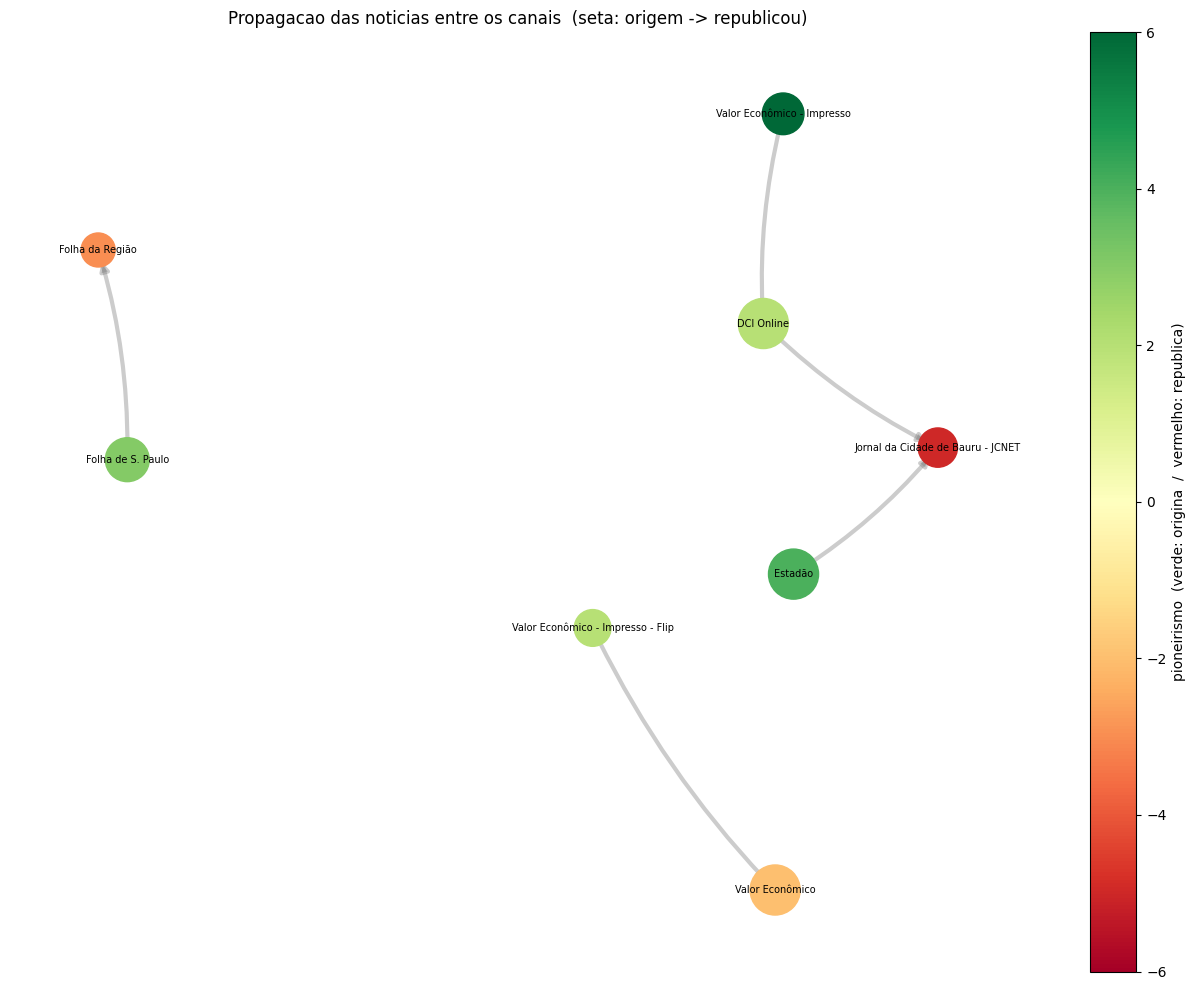

In [13]:
GP = nx.DiGraph()
for _, r in edges.iterrows():
    if r['peso'] >= MIN_PESO_ARESTA:
        GP.add_edge(r['origem'], r['seguidor'], weight=r['peso'])

graus = dict(GP.degree(weight='weight'))
keep  = [n for n, _ in sorted(graus.items(), key=lambda x: -x[1])[:TOP_FONTES_PLOT]]
H = GP.subgraph(keep).copy()

pion = {n: origem_count[n] - seguidor_count[n] for n in H.nodes}
vlim = max([abs(v) for v in pion.values()] + [1])

pos = nx.spring_layout(H, k=0.9, seed=SEED, weight='weight')
plt.figure(figsize=(13, 10))
nsize = [300 + 100*(origem_count[n] + seguidor_count[n]) for n in H.nodes]
nodes = nx.draw_networkx_nodes(H, pos, node_size=nsize,
            node_color=[pion[n] for n in H.nodes],
            cmap='RdYlGn', vmin=-vlim, vmax=vlim)
w = np.array([H[u][v]['weight'] for u, v in H.edges], dtype=float)
nx.draw_networkx_edges(H, pos, width=0.5 + 2.5*w/w.max(), alpha=.4,
            edge_color='gray', arrowsize=12, connectionstyle='arc3,rad=0.08')
nx.draw_networkx_labels(H, pos, font_size=7)
plt.colorbar(nodes, label='pioneirismo  (verde: origina  /  vermelho: republica)')
plt.title('Propagacao das noticias entre os canais  (seta: origem -> republicou)')
plt.axis('off'); plt.tight_layout(); plt.show()

## 10. Ranking: quem dá a notícia primeiro x quem republica

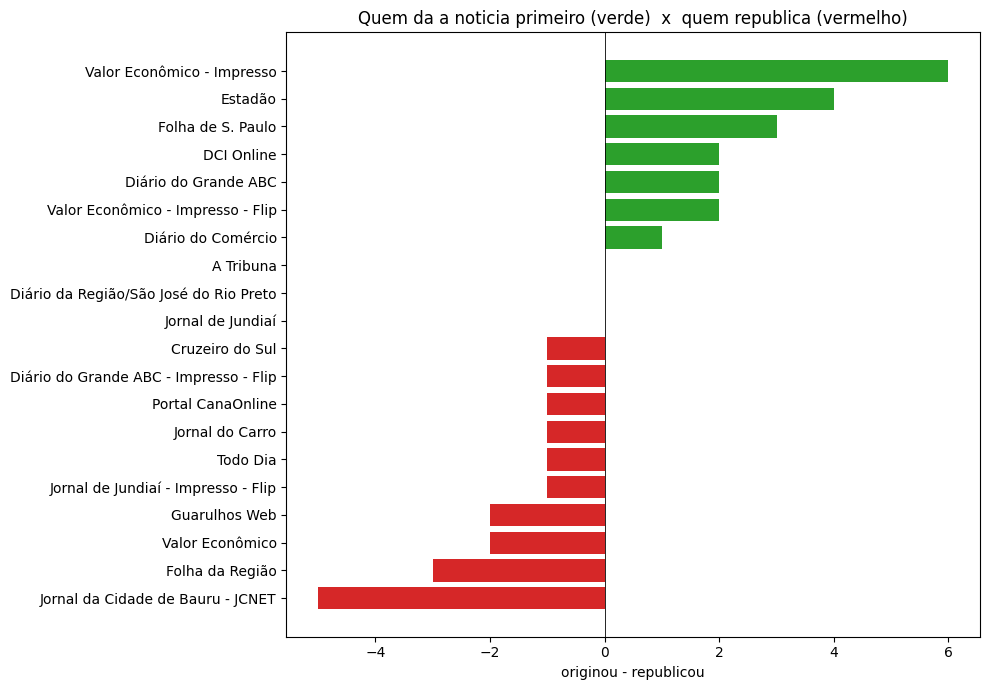

,fonte,originou,republicou,pioneirismo
0,Valor Econômico - Impresso,6,0,6
1,Estadão,7,3,4
2,Folha de S. Paulo,5,2,3
3,DCI Online,6,4,2
4,Diário do Grande ABC,5,3,2
5,Valor Econômico - Impresso - Flip,3,1,2
6,Diário do Comércio,1,0,1
7,A Tribuna,2,2,0
8,Diário da Região/São José do Rio Preto,1,1,0
9,Jornal de Jundiaí,1,1,0


In [14]:
fontes = sorted(set(list(origem_count) + list(seguidor_count)))
rank = pd.DataFrame({'fonte': fontes})
rank['originou']    = rank.fonte.map(lambda f: origem_count.get(f, 0))
rank['republicou']  = rank.fonte.map(lambda f: seguidor_count.get(f, 0))
rank['pioneirismo'] = rank['originou'] - rank['republicou']
rank = rank.sort_values('pioneirismo', ascending=False).reset_index(drop=True)

top = pd.concat([rank.head(10), rank.tail(10)])
plt.figure(figsize=(10, 7))
plt.barh(top.fonte[::-1], top.pioneirismo[::-1],
         color=['#2ca02c' if v > 0 else '#d62728' for v in top.pioneirismo[::-1]])
plt.axvline(0, c='k', lw=.6)
plt.title('Quem da a noticia primeiro (verde)  x  quem republica (vermelho)')
plt.xlabel('originou - republicou'); plt.tight_layout(); plt.show()

rank.head(15)

## 11. Exportar resultados

In [15]:
df.to_csv('noticias_com_cluster.csv', index=False)
edges.to_csv('propagacao_fonte_a_fonte.csv', index=False)
rank.to_csv('ranking_pioneirismo.csv', index=False)
pd.DataFrame([{'sim': s, 'i': i, 'j': j,
               'fonte_i': df.fonte[i], 'fonte_j': df.fonte[j],
               'dia_i': df.dia[i].date(), 'dia_j': df.dia[j].date(),
               'titulo_i': df.titulo[i], 'titulo_j': df.titulo[j]}
              for s, i, j in dups]).to_csv('pares_duplicados.csv', index=False)
print('salvos: noticias_com_cluster.csv | propagacao_fonte_a_fonte.csv | '
      'ranking_pioneirismo.csv | pares_duplicados.csv')

salvos: noticias_com_cluster.csv | propagacao_fonte_a_fonte.csv | ranking_pioneirismo.csv | pares_duplicados.csv
